In [1]:
from pathlib import Path
from tqdm import tqdm
import math
import torch
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset, concatenate_datasets, Dataset
from tokenizers import Tokenizer
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
wikimatrix = load_dataset("sentence-transformers/parallel-sentences-wikimatrix", "en-zh")["train"]
opensubtitles = load_dataset("sentence-transformers/parallel-sentences-opensubtitles", "en-zh_cn")["train"]
talks = load_dataset("sentence-transformers/parallel-sentences-talks", "en-zh-cn")["train"]
tatoeba = load_dataset("sentence-transformers/parallel-sentences-tatoeba", "en-zh")["train"]
# ccmatrix = load_dataset("sentence-transformers/parallel-sentences-ccmatrix", "en-zh")["train"]

raw_dataset = concatenate_datasets([wikimatrix, opensubtitles, talks, tatoeba])

Resolving data files:   0%|          | 0/23 [00:00<?, ?it/s]

In [3]:
def dataset_processing(dataset: Dataset, squence_length: int = 512):
    def chinese_rule(code: int):
        return code < 128 or 0x4E00 <= code <= 0x9FFF or 0x3000 <= code <= 0x303F or 0xFF01 <= code <= 0xFF5E

    def english_rule(code: int):
        return code < 128 or 0x3000 <= code <= 0x303F or 0xFF01 <= code <= 0xFF5E

    squence_length = squence_length - 2

    en_list: list[str] = []
    zh_list: list[str] = []
    for data in tqdm(dataset, desc="pre-processing"):
        en = data["english"]
        zh = data["non_english"]
        if len(en) > squence_length or len(zh) > squence_length:
            continue
        if all([english_rule(ord(c)) for c in en]) and all([chinese_rule(ord(c)) for c in zh]):
            en_list.append(en)
            zh_list.append(zh)
    print(f"训练句对长度: {len(en_list)}")
    return en_list, zh_list


en_list, zh_list = dataset_processing(raw_dataset)

en_tokenizer_path = Path("en_tokenizer.json")
zh_tokenizer_path = Path("zh_tokenizer.json")

if en_tokenizer_path.exists() and zh_tokenizer_path.exists():
    en_tokenizer = Tokenizer.from_file(en_tokenizer_path.as_posix())
    zh_tokenizer = Tokenizer.from_file(zh_tokenizer_path.as_posix())
else:

    from tokenizers import models, trainers, pre_tokenizers

    en_vocab_size = 25000
    zh_vocab_size = 25000
    min_frequency = 2

    special_tokens = ["[PAD]", "[UNK]", "[SOS]", "[EOS]"]
    continuing_subword_prefix = "##"
    # 英文分词器
    en_tokenizer = Tokenizer(models.WordPiece(unk_token="[UNK]"))
    en_tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

    en_trainer = trainers.WordPieceTrainer(
        vocab_size=en_vocab_size,
        min_frequency=min_frequency,
        special_tokens=special_tokens + [".", ",", "!", "?", ";", ":"],
        continuing_subword_prefix=continuing_subword_prefix,
    )
    en_tokenizer.train_from_iterator(en_list, trainer=en_trainer)
    # 中文分词器
    zh_tokenizer = Tokenizer(models.WordPiece(unk_token="[UNK]"))
    zh_tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
    zh_trainer = trainers.WordPieceTrainer(
        vocab_size=zh_vocab_size,
        min_frequency=min_frequency,
        special_tokens=special_tokens + [".", ",", "!", "?", ";", ":"] + [chr(i) for i in range(0x3000, 0x303F)],
        continuing_subword_prefix=continuing_subword_prefix,
    )
    zh_tokenizer.train_from_iterator(zh_list, trainer=zh_trainer)
    # 处理文本编码
    en_tokenizer.save(en_tokenizer_path.as_posix())
    zh_tokenizer.save(zh_tokenizer_path.as_posix())

PAD, UNK, SOS, EOS = 0, 1, 2, 3
assert en_tokenizer.token_to_id("[PAD]") == zh_tokenizer.token_to_id("[PAD]") == PAD
assert en_tokenizer.token_to_id("[UNK]") == zh_tokenizer.token_to_id("[UNK]") == UNK
assert en_tokenizer.token_to_id("[SOS]") == zh_tokenizer.token_to_id("[SOS]") == SOS
assert en_tokenizer.token_to_id("[EOS]") == zh_tokenizer.token_to_id("[EOS]") == EOS

en_dataset = [torch.tensor([SOS] + en_tokenizer.encode(text).ids + [EOS], device=DEVICE) for text in tqdm(en_list, desc="build en")]
zh_dataset = [torch.tensor([SOS] + zh_tokenizer.encode(text).ids + [EOS], device=DEVICE) for text in tqdm(zh_list, desc="build zh")]
dataset = [(en, zh) for en, zh in zip(en_dataset, zh_dataset)]

pre-processing: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 874236/874236 [00:26<00:00, 32554.10it/s]


训练句对长度: 794938


build zh: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 794938/794938 [01:05<00:00, 12126.46it/s]


In [ ]:
def train(
    model: torch.nn.Module,
    loader: DataLoader,
    num_epochs=10,
    lr: float = 0.001,
    save_path: Path | None = None,
    lossi: list | None = None,
):
    print("模型参数：", sum(p.numel() for p in model.parameters() if p.requires_grad))
    model.train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss(ignore_index=PAD)
    lossi = [] if lossi is None else lossi
    for epoch in range(num_epochs):
        for inputs, targets in tqdm(loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            loss = criterion(model.forward(inputs, targets[:, :-1]).transpose(-2, -1), targets[:, 1:])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            lossi.append(loss.item())
        print(f"Current Loss {lossi[-1]:.4f}")
        if save_path is not None:
            torch.save(model, save_path / f"model{epoch+1}.pth")
        torch.cuda.empty_cache()
    return lossi

In [5]:
class TransformerEDM(torch.nn.Module):
    def __init__(
        self,
        enc_vs: int,
        dec_vs: int,
        emb_size: int,
        head_size: int,
        n_block: int,
        sequence_length: int,
    ):
        super().__init__()
        # 编码器
        self.enc_token_emb = torch.nn.Embedding(enc_vs, emb_size)
        self.enc_position_emb = torch.nn.Embedding(sequence_length, emb_size)
        # 解码器
        self.dec_token_emb = torch.nn.Embedding(dec_vs, emb_size)
        self.dec_position_emb = torch.nn.Embedding(sequence_length, emb_size)
        self.dec_fc_out = torch.nn.Linear(emb_size, dec_vs)
        assert emb_size % head_size == 0
        nhead = emb_size // head_size
        self.transformer = torch.nn.Transformer(
            num_encoder_layers=n_block,
            num_decoder_layers=n_block,
            d_model=emb_size,
            nhead=nhead,
            dim_feedforward=emb_size * 4,
            activation="gelu",
            batch_first=True,
        )
        self.position: torch.Tensor
        self.register_buffer("position", torch.arange(0, sequence_length, dtype=torch.long))
        self.mask: torch.Tensor
        self.register_buffer("mask", self.transformer.generate_square_subsequent_mask(sequence_length, dtype=torch.bool))

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor):
        T_src = inputs.size(-1)
        T_tgt = targets.size(-1)
        encoding = self.enc_token_emb(inputs) + self.enc_position_emb(self.position[:T_src])
        decoding = self.dec_token_emb(targets) + self.dec_position_emb(self.position[:T_tgt])
        logits = self.transformer.forward(
            encoding,
            decoding,
            tgt_mask=self.mask[:T_tgt, :T_tgt],
            src_key_padding_mask=(inputs == PAD),
            tgt_key_padding_mask=(targets == PAD),
        )
        return self.dec_fc_out(logits)

In [17]:
model_file = Path("model.pth")
if model_file.exists():
    model = torch.load(model_file, weights_only=False).to(DEVICE)
else:
    model = TransformerEDM(
        enc_vs=en_tokenizer.get_vocab_size(),
        dec_vs=zh_tokenizer.get_vocab_size(),
        emb_size=256,
        head_size=32,
        n_block=2,
        sequence_length=512,
    ).to(DEVICE)

In [18]:
torch.cuda.empty_cache()

In [19]:
def collate_fn(batch):
    en_batch, zh_batch = zip(*batch)
    en_batch = pad_sequence(en_batch, batch_first=True)
    zh_batch = pad_sequence(zh_batch, batch_first=True)
    return en_batch, zh_batch


train_loader = DataLoader(dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)

In [ ]:
lossi = []

In [20]:
train(model, train_loader, num_epochs=19, save_path=Path(), lossi=lossi)

模型参数： 23174568


Epoch 1/19: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 49684/49684 [21:42<00:00, 38.15it/s]


Current Loss 5.9963


Epoch 2/19: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 49684/49684 [18:28<00:00, 44.83it/s]


Current Loss 6.0400


...

Epoch 18/19: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 49684/49684 [18:27<00:00, 44.85it/s]


Current Loss 4.3248


Epoch 19/19: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 49684/49684 [18:26<00:00, 44.89it/s]


Current Loss 4.8672


[10.274773597717285,
 9.79903507232666,
 9.667285919189453,
 9.469945907592773,
 9.37787914276123,
 9.093058586120605,
 9.09446907043457,
 9.314126014709473,
 8.866116523742676,
 8.892440795898438,
 8.77446460723877,
 8.736213684082031,
 8.486227035522461,
 8.749313354492188,
 8.705536842346191,
 8.773528099060059,
 8.841102600097656,
 8.611801147460938,
 8.485763549804688,
 8.74354362487793,
 8.600111961364746,
 8.59097957611084,
 8.425137519836426,
 8.490354537963867,
 8.687509536743164,
 8.625704765319824,
 8.527743339538574,
 8.651128768920898,
 8.708518028259277,
 8.454405784606934,
 8.448915481567383,
 8.537842750549316,
 8.445494651794434,
 8.573653221130371,
 8.518630981445312,
 8.715211868286133,
 8.398058891296387,
 8.232925415039062,
 8.515120506286621,
 8.179191589355469,
 8.096003532409668,
 8.229988098144531,
 8.211788177490234,
 8.59473705291748,
 8.381799697875977,
 8.754426956176758,
 8.243965148925781,
 8.565441131591797,
 8.2987699508667,
 8.355074882507324,
 8.45535

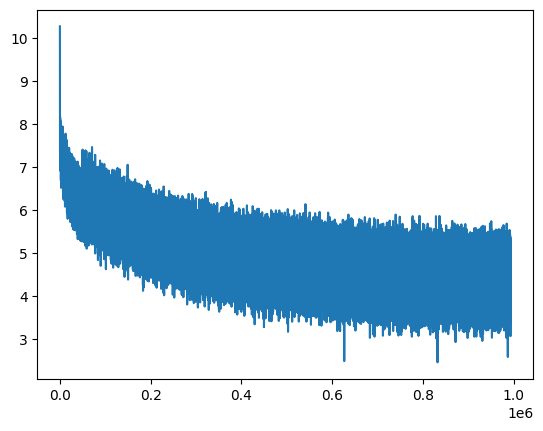

In [21]:
plt.plot(torch.tensor(lossi))
plt.show()

In [22]:
class Translator:
    def __init__(self, source_tokenizer: Tokenizer, target_tokenizer: Tokenizer, model: TransformerEDM):
        self.source_tokenizer = source_tokenizer
        self.target_tokenizer = target_tokenizer
        self.pad_ind = self.target_tokenizer.token_to_id("[PAD]")
        self.unk_ind = self.target_tokenizer.token_to_id("[UNK]")
        self.sos_ind = self.target_tokenizer.token_to_id("[SOS]")
        self.eos_ind = self.target_tokenizer.token_to_id("[EOS]")
        self.model = model
        self.sequence_length = model.position.size(0)

    @torch.no_grad()
    def generate(self, source: str, device=DEVICE) -> str:
        source_ids = self.source_tokenizer.encode(source).ids
        source_ids.append(self.eos_ind)
        inputs = torch.tensor(source_ids, dtype=torch.long, device=device).unsqueeze(0)
        targets = torch.tensor([self.sos_ind], dtype=torch.long, device=device).unsqueeze(0)
        for i in range(self.sequence_length):
            output = self.model(inputs, targets)
            next_token = output[:, -1, :].argmax(dim=-1, keepdim=True)
            targets = torch.cat([targets, next_token], dim=-1)
        target_ids = targets.squeeze(0).tolist()
        return self.target_tokenizer.decode(target_ids, skip_special_tokens=False)

In [23]:
translator = Translator(en_tokenizer, zh_tokenizer, model=model)

In [24]:
print(translator.generate("I love You"))

[SOS] - 你 ##爱 [EOS] ##人 [EOS] [EOS] [EOS] ##子 [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] ##你 [EOS] ##爱的 [EOS] [EOS] [EOS] [EOS] [EOS] ##你 [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] ##你 [EOS] [EOS] [EOS] [EOS] ##的 [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] ##的 [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] ##的 [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [EOS] [